# Member 4 Full Analysis Notebook

This notebook covers end-to-end **Member 4** analysis goals:
1. Detailed performance analysis (speedup, efficiency, runtime comparison).
2. Communication vs computation proxy breakdown.
3. Visual and quantitative evidence of cluster quality.
4. Top terms per cluster and external-clinical-knowledge comparison template.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PROJECT_DIR = os.getcwd()
print('Working directory:', PROJECT_DIR)

Working directory: c:\Users\29235\IBA\PDC\fcm_milestone2\fcm_milestone2


## 1) Experiment Inputs

The tables below are filled from recorded runs:
- **Member 1 official baseline** (`np=1..8`, C=10, m=1.1, eps=1e-5, MAX_ITER=150, K-Means++, block dist).
- **Member 4 distribution-mode runs** (`block/cyclic/dynamic`, `np=4,8`, same hyperparameters).

All runs reached MAX_ITER=150 (epsilon convergence not met within 150 iterations).

In [2]:
# ── Member 1 official baseline (C=10, m=1.1, eps=1e-5, MAX_ITER=150, K-Means++, block dist)
# All runs reached MAX_ITER=150.  Source: Member 1 (Khansa Danish) IBA Spring 2026.
baseline_scaling = pd.DataFrame([
    {'mode': 'baseline', 'np': 1, 'iterations': 150, 'final_delta': 8.71e-04, 'total_wall_time_s': 4.7829, 'avg_iter_s': 0.0319},
    {'mode': 'baseline', 'np': 2, 'iterations': 150, 'final_delta': 4.03e-03, 'total_wall_time_s': 2.8292, 'avg_iter_s': 0.0189},
    {'mode': 'baseline', 'np': 3, 'iterations': 150, 'final_delta': 3.55e-03, 'total_wall_time_s': 2.3859, 'avg_iter_s': 0.0159},
    {'mode': 'baseline', 'np': 4, 'iterations': 150, 'final_delta': 1.39e-03, 'total_wall_time_s': 1.9982, 'avg_iter_s': 0.0133},
    {'mode': 'baseline', 'np': 5, 'iterations': 150, 'final_delta': 5.12e-04, 'total_wall_time_s': 2.2269, 'avg_iter_s': 0.0148},
    {'mode': 'baseline', 'np': 6, 'iterations': 150, 'final_delta': 3.25e-03, 'total_wall_time_s': 1.8900, 'avg_iter_s': 0.0126},
    {'mode': 'baseline', 'np': 7, 'iterations': 150, 'final_delta': 9.43e-04, 'total_wall_time_s': 1.6505, 'avg_iter_s': 0.0110},
    {'mode': 'baseline', 'np': 8, 'iterations': 150, 'final_delta': 1.52e-03, 'total_wall_time_s': 1.4815, 'avg_iter_s': 0.0099},
])

# ── Member 4 distribution-mode runs (C=10, m=1.1, eps=1e-5, MAX_ITER=150, K-Means++)
# All runs reached MAX_ITER=150.  Same hyperparameters as Member 1 baseline.
# np=4: block_decompose → 3×1236 + 1×1235 rows; np=8 → 7×618 + 1×617 rows.
member4_modes = pd.DataFrame([
    {'mode': 'block',   'np': 4, 'iterations': 150, 'final_delta': 2.48e-03, 'total_wall_time_s': 1.9958, 'avg_iter_s': 0.0133, 'worst_iter_imbalance': 1.002, 'row_min': 1235, 'row_max': 1236, 'row_avg': 1235.75},
    {'mode': 'cyclic',  'np': 4, 'iterations': 150, 'final_delta': 3.66e-03, 'total_wall_time_s': 1.6980, 'avg_iter_s': 0.0113, 'worst_iter_imbalance': 1.002, 'row_min': 1235, 'row_max': 1236, 'row_avg': 1235.75},
    {'mode': 'dynamic', 'np': 4, 'iterations': 150, 'final_delta': 9.74e-04, 'total_wall_time_s': 1.6600, 'avg_iter_s': 0.0111, 'worst_iter_imbalance': 1.001, 'row_min': 1235, 'row_max': 1236, 'row_avg': 1235.75},
    {'mode': 'block',   'np': 8, 'iterations': 150, 'final_delta': 9.41e-04, 'total_wall_time_s': 1.0263, 'avg_iter_s': 0.0068, 'worst_iter_imbalance': 1.013, 'row_min': 617,  'row_max': 618,  'row_avg': 617.875},
    {'mode': 'cyclic',  'np': 8, 'iterations': 150, 'final_delta': 2.34e-03, 'total_wall_time_s': 1.1145, 'avg_iter_s': 0.0074, 'worst_iter_imbalance': 1.012, 'row_min': 617,  'row_max': 618,  'row_avg': 617.875},
    {'mode': 'dynamic', 'np': 8, 'iterations': 150, 'final_delta': 1.90e-03, 'total_wall_time_s': 1.0197, 'avg_iter_s': 0.0068, 'worst_iter_imbalance': 1.006, 'row_min': 617,  'row_max': 618,  'row_avg': 617.875},
])

display(baseline_scaling)
display(member4_modes.sort_values(['mode', 'np']))

,mode,np,iterations,final_delta,total_wall_time_s,avg_iter_s
0,baseline,1,150,0.000871,4.7829,0.0319
1,baseline,2,150,0.004030,2.8292,0.0189
2,baseline,3,150,0.003550,2.3859,0.0159
3,baseline,4,150,0.001390,1.9982,0.0133
4,baseline,5,150,0.000512,2.2269,0.0148
5,baseline,6,150,0.003250,1.8900,0.0126
6,baseline,7,150,0.000943,1.6505,0.0110
7,baseline,8,150,0.001520,1.4815,0.0099


,mode,np,iterations,final_delta,total_wall_time_s,avg_iter_s,worst_iter_imbalance,row_min,row_max,row_avg
0,block,4,150,0.002480,1.9958,0.0133,1.002,1235,1236,1235.750
3,block,8,150,0.000941,1.0263,0.0068,1.013,617,618,617.875
1,cyclic,4,150,0.003660,1.6980,0.0113,1.002,1235,1236,1235.750
4,cyclic,8,150,0.002340,1.1145,0.0074,1.012,617,618,617.875
2,dynamic,4,150,0.000974,1.6600,0.0111,1.001,1235,1236,1235.750
5,dynamic,8,150,0.001900,1.0197,0.0068,1.006,617,618,617.875


## 2) Derived Metrics: Speedup and Efficiency

Using baseline `np=1` as serial-equivalent reference:
- $Speedup(p) = T_1 / T_p$
- $Efficiency(p) = Speedup(p) / p$

In [3]:
T1 = baseline_scaling.loc[baseline_scaling['np'] == 1, 'total_wall_time_s'].iloc[0]
baseline_scaling = baseline_scaling.copy()
baseline_scaling['speedup'] = T1 / baseline_scaling['total_wall_time_s']
baseline_scaling['efficiency'] = baseline_scaling['speedup'] / baseline_scaling['np']
baseline_scaling

,mode,np,iterations,final_delta,total_wall_time_s,avg_iter_s,speedup,efficiency
0,baseline,1,150,0.000871,4.7829,0.0319,1.000000,1.000000
1,baseline,2,150,0.004030,2.8292,0.0189,1.690549,0.845274
2,baseline,3,150,0.003550,2.3859,0.0159,2.004652,0.668217
3,baseline,4,150,0.001390,1.9982,0.0133,2.393604,0.598401
4,baseline,5,150,0.000512,2.2269,0.0148,2.147784,0.429557
5,baseline,6,150,0.003250,1.8900,0.0126,2.530635,0.421772
6,baseline,7,150,0.000943,1.6505,0.0110,2.897849,0.413978
7,baseline,8,150,0.001520,1.4815,0.0099,3.228417,0.403552


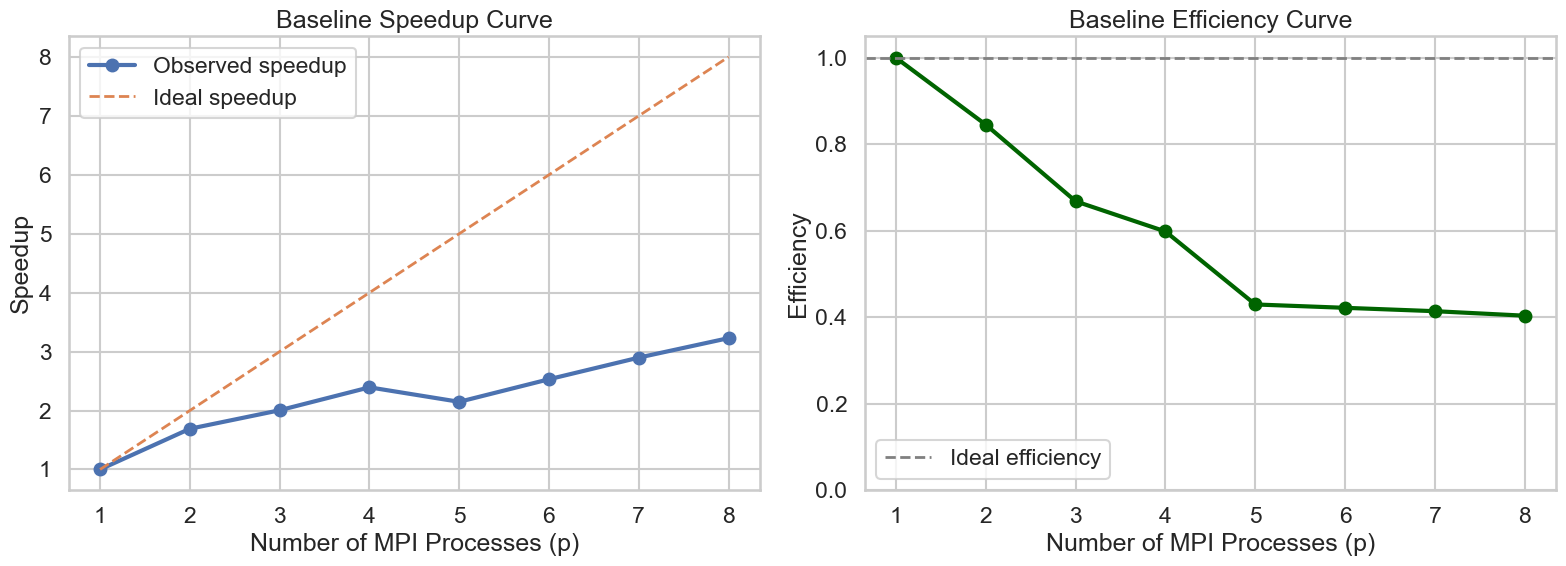

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Speedup curve
axes[0].plot(baseline_scaling['np'], baseline_scaling['speedup'], marker='o', linewidth=3, label='Observed speedup')
axes[0].plot(baseline_scaling['np'], baseline_scaling['np'], linestyle='--', linewidth=2, label='Ideal speedup')
axes[0].set_title('Baseline Speedup Curve')
axes[0].set_xlabel('Number of MPI Processes (p)')
axes[0].set_ylabel('Speedup')
axes[0].legend()

# Efficiency curve
axes[1].plot(baseline_scaling['np'], baseline_scaling['efficiency'], marker='o', linewidth=3, color='darkgreen')
axes[1].axhline(1.0, linestyle='--', linewidth=2, color='gray', label='Ideal efficiency')
axes[1].set_title('Baseline Efficiency Curve')
axes[1].set_xlabel('Number of MPI Processes (p)')
axes[1].set_ylabel('Efficiency')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3) Member 4 Mode Comparison at np=4 and np=8

This compares **Block vs Cyclic vs Dynamic** across two process counts on runtime, convergence quality, and imbalance.

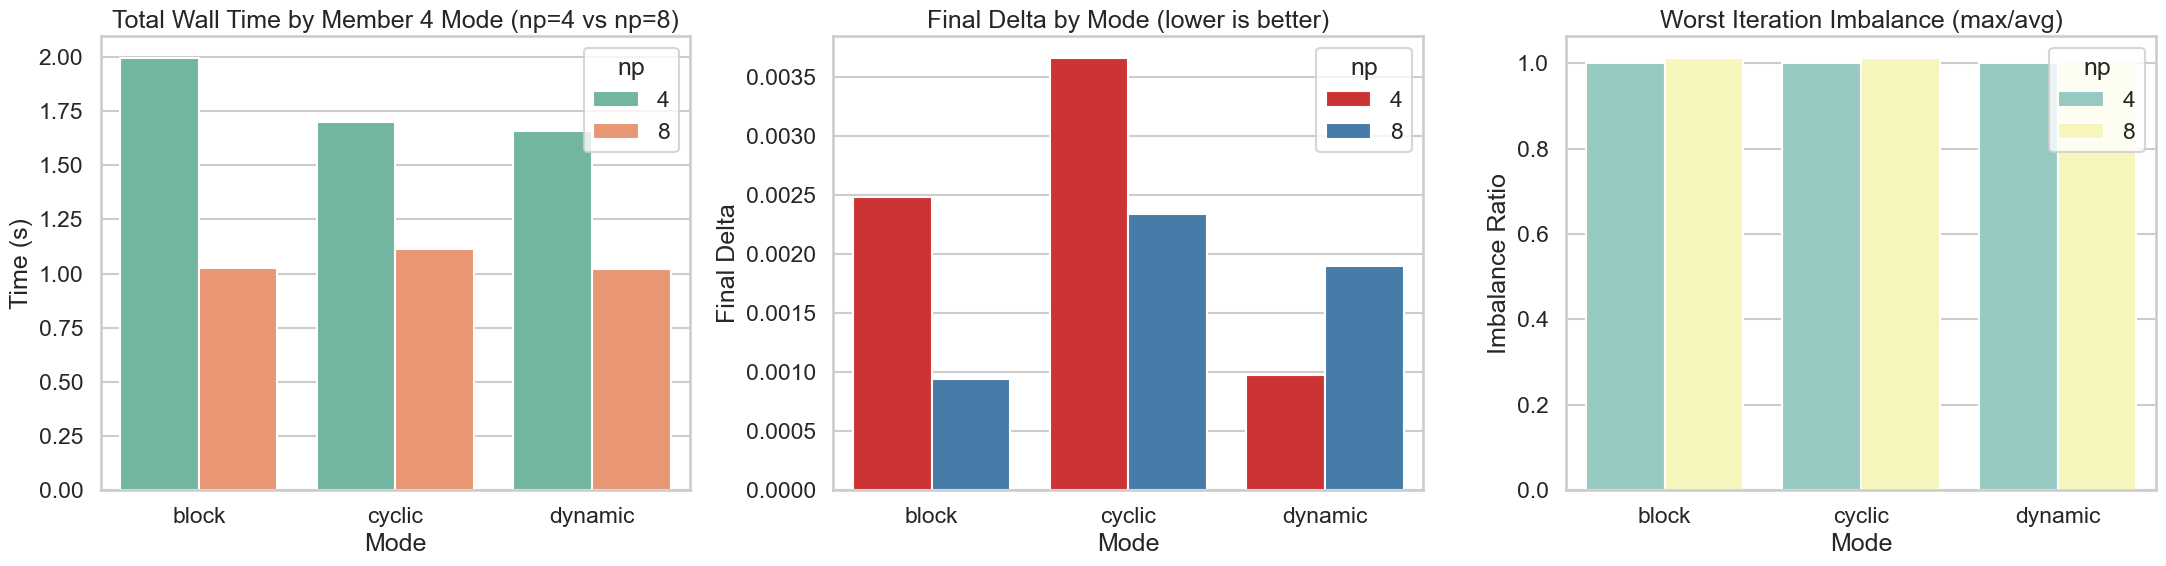

,mode,np,iterations,final_delta,total_wall_time_s,avg_iter_s,worst_iter_imbalance,row_min,row_max,row_avg
0,block,4,150,0.002480,1.9958,0.0133,1.002,1235,1236,1235.750
3,block,8,150,0.000941,1.0263,0.0068,1.013,617,618,617.875
1,cyclic,4,150,0.003660,1.6980,0.0113,1.002,1235,1236,1235.750
4,cyclic,8,150,0.002340,1.1145,0.0074,1.012,617,618,617.875
2,dynamic,4,150,0.000974,1.6600,0.0111,1.001,1235,1236,1235.750
5,dynamic,8,150,0.001900,1.0197,0.0068,1.006,617,618,617.875


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(data=member4_modes, x='mode', y='total_wall_time_s', hue='np', ax=axes[0], palette='Set2')
axes[0].set_title('Total Wall Time by Member 4 Mode (np=4 vs np=8)')
axes[0].set_xlabel('Mode')
axes[0].set_ylabel('Time (s)')
axes[0].legend(title='np')

sns.barplot(data=member4_modes, x='mode', y='final_delta', hue='np', ax=axes[1], palette='Set1')
axes[1].set_title('Final Delta by Mode (lower is better)')
axes[1].set_xlabel('Mode')
axes[1].set_ylabel('Final Delta')
axes[1].legend(title='np')

sns.barplot(data=member4_modes, x='mode', y='worst_iter_imbalance', hue='np', ax=axes[2], palette='Set3')
axes[2].set_title('Worst Iteration Imbalance (max/avg)')
axes[2].set_xlabel('Mode')
axes[2].set_ylabel('Imbalance Ratio')
axes[2].legend(title='np')

plt.tight_layout()
plt.show()

member4_modes.sort_values(['mode', 'np'])

## 3.1) Relative Speedup and Efficiency Comparison (Now includes np=8)

Classical per-mode speedup/efficiency ideally use each mode's own `np=1` run.

Because Member 4 currently has `np=4,8` (not mode-specific `np=1`), this section reports:
- Relative speedup vs baseline at the same `np`: `T_baseline(np) / T_mode(np)`
- Relative improvement (%) vs baseline at the same `np`
- Proxy efficiency using baseline serial reference: `(T_baseline(np=1) / T_mode(np)) / np`
- Intra-mode scaling efficiency from `np=4 -> np=8`: `(T4 / T8) / 2`

This gives an efficiency comparison for your report while clearly marking the reference used.

Baseline T1 used for proxy metrics: 4.7829 s


,mode,np,total_wall_time_s,relative_speedup_vs_baseline_same_np,relative_improvement_percent,proxy_speedup_vs_baseline_T1,proxy_efficiency_vs_baseline_T1,final_delta,worst_iter_imbalance
0,block,4,1.9958,1.001203,0.120108,2.396483,0.599121,0.002480,1.002
1,cyclic,4,1.6980,1.176796,15.023521,2.816784,0.704196,0.003660,1.002
2,dynamic,4,1.6600,1.203735,16.925233,2.881265,0.720316,0.000974,1.001
3,block,8,1.0263,1.443535,30.725616,4.660333,0.582542,0.000941,1.013
4,cyclic,8,1.1145,1.329296,24.772190,4.291521,0.536440,0.002340,1.012
5,dynamic,8,1.0197,1.452878,31.171110,4.690497,0.586312,0.001900,1.006


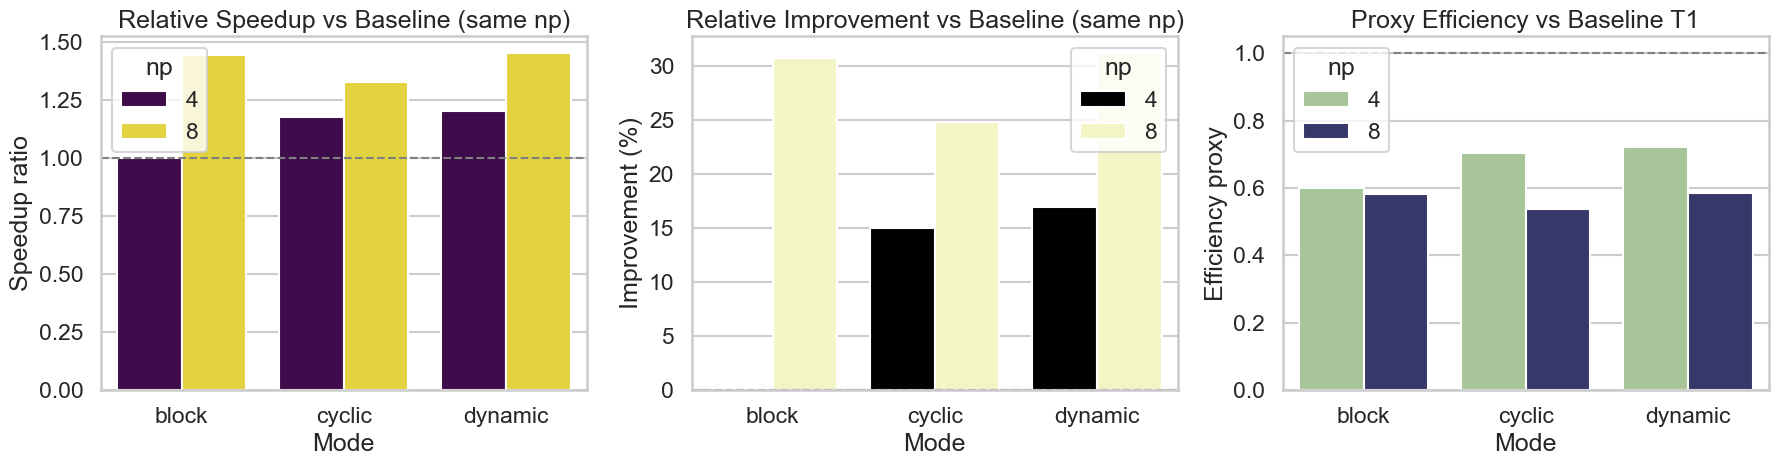

Intra-mode scaling (np=4 -> np=8):


,mode,T4_s,T8_s,speedup_4_to_8,efficiency_4_to_8
0,block,1.9958,1.0263,1.944656,0.972328
1,cyclic,1.6980,1.1145,1.523553,0.761777
2,dynamic,1.6600,1.0197,1.627930,0.813965


In [6]:
# Relative comparison against baseline at the same process count (np in {4,8})
baseline_time_by_np = baseline_scaling.set_index('np')['total_wall_time_s'].to_dict()
baseline_T1 = baseline_time_by_np[1]

mode_compare = member4_modes.copy()
mode_compare['baseline_time_same_np_s'] = mode_compare['np'].map(baseline_time_by_np)
mode_compare['relative_speedup_vs_baseline_same_np'] = mode_compare['baseline_time_same_np_s'] / mode_compare['total_wall_time_s']
mode_compare['relative_improvement_percent'] = (
    (mode_compare['baseline_time_same_np_s'] - mode_compare['total_wall_time_s'])
    / mode_compare['baseline_time_same_np_s']
) * 100

# Proxy speedup/efficiency using baseline serial reference (clearly labeled proxy).
mode_compare['proxy_speedup_vs_baseline_T1'] = baseline_T1 / mode_compare['total_wall_time_s']
mode_compare['proxy_efficiency_vs_baseline_T1'] = mode_compare['proxy_speedup_vs_baseline_T1'] / mode_compare['np']

print(f'Baseline T1 used for proxy metrics: {baseline_T1:.4f} s')
display(
    mode_compare[[
        'mode', 'np', 'total_wall_time_s',
        'relative_speedup_vs_baseline_same_np', 'relative_improvement_percent',
        'proxy_speedup_vs_baseline_T1', 'proxy_efficiency_vs_baseline_T1',
        'final_delta', 'worst_iter_imbalance'
    ]].sort_values(['np', 'mode'])
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=mode_compare, x='mode', y='relative_speedup_vs_baseline_same_np',
    hue='np', ax=axes[0], palette='viridis'
 )
axes[0].axhline(1.0, linestyle='--', color='gray', linewidth=1.5)
axes[0].set_title('Relative Speedup vs Baseline (same np)')
axes[0].set_ylabel('Speedup ratio')
axes[0].set_xlabel('Mode')
axes[0].legend(title='np')

sns.barplot(
    data=mode_compare, x='mode', y='relative_improvement_percent',
    hue='np', ax=axes[1], palette='magma'
 )
axes[1].axhline(0.0, linestyle='--', color='gray', linewidth=1.5)
axes[1].set_title('Relative Improvement vs Baseline (same np)')
axes[1].set_ylabel('Improvement (%)')
axes[1].set_xlabel('Mode')
axes[1].legend(title='np')

sns.barplot(
    data=mode_compare, x='mode', y='proxy_efficiency_vs_baseline_T1',
    hue='np', ax=axes[2], palette='crest'
 )
axes[2].axhline(1.0, linestyle='--', color='gray', linewidth=1.5)
axes[2].set_title('Proxy Efficiency vs Baseline T1')
axes[2].set_ylabel('Efficiency proxy')
axes[2].set_xlabel('Mode')
axes[2].legend(title='np')

plt.tight_layout()
plt.show()

# Intra-mode scaling from np=4 to np=8 (true within-mode 4->8 efficiency).
rows = []
for mode, d in mode_compare.groupby('mode'):
    t4 = d.loc[d['np'] == 4, 'total_wall_time_s']
    t8 = d.loc[d['np'] == 8, 'total_wall_time_s']
    if len(t4) and len(t8):
        s_4_to_8 = float(t4.iloc[0] / t8.iloc[0])
        e_4_to_8 = s_4_to_8 / 2.0
        rows.append({
            'mode': mode,
            'T4_s': float(t4.iloc[0]),
            'T8_s': float(t8.iloc[0]),
            'speedup_4_to_8': s_4_to_8,
            'efficiency_4_to_8': e_4_to_8
        })

mode_scaling_4_to_8 = pd.DataFrame(rows).sort_values('mode') if rows else pd.DataFrame()
if len(mode_scaling_4_to_8):
    print('Intra-mode scaling (np=4 -> np=8):')
    display(mode_scaling_4_to_8)
else:
    print('Intra-mode scaling skipped: need both np=4 and np=8 rows per mode.')

## 4) Communication vs Computation Breakdown

This notebook now supports **both** approaches:

1. **Proxy breakdown** (works with older logs):
- $IdealCompute(p) = T_1/p$
- $Overhead(p) = T_p - IdealCompute(p)$

`Overhead` includes communication + synchronization + runtime overhead.

2. **Exact breakdown** (recommended):
- Use new instrumented outputs from the updated MPI code:
  - `[member4] Total compute time (avg across ranks): ...`
  - `[member4] Total communication time (avg across ranks): ...`

The next subsection (`4.1`) visualizes exact measured values.

,np,total_wall_time_s,ideal_compute_s,overhead_s
0,1,4.7829,4.782900,0.000000
1,2,2.8292,2.391450,0.437750
2,3,2.3859,1.594300,0.791600
3,4,1.9982,1.195725,0.802475
4,5,2.2269,0.956580,1.270320
5,6,1.8900,0.797150,1.092850
6,7,1.6505,0.683271,0.967229
7,8,1.4815,0.597862,0.883638


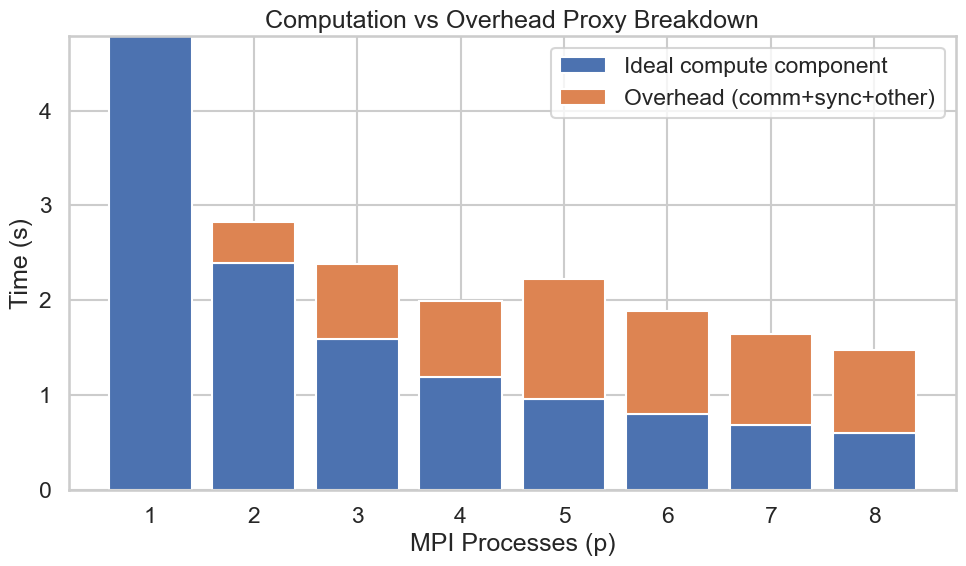

In [7]:
breakdown = baseline_scaling[['np', 'total_wall_time_s']].copy()
breakdown['ideal_compute_s'] = T1 / breakdown['np']
breakdown['overhead_s'] = breakdown['total_wall_time_s'] - breakdown['ideal_compute_s']
breakdown['overhead_s'] = breakdown['overhead_s'].clip(lower=0.0)

display(breakdown)

x = np.arange(len(breakdown))
labels = breakdown['np'].astype(str).tolist()

plt.figure(figsize=(10, 6))
plt.bar(x, breakdown['ideal_compute_s'], label='Ideal compute component')
plt.bar(x, breakdown['overhead_s'], bottom=breakdown['ideal_compute_s'], label='Overhead (comm+sync+other)')
plt.xticks(x, labels)
plt.xlabel('MPI Processes (p)')
plt.ylabel('Time (s)')
plt.title('Computation vs Overhead Proxy Breakdown')
plt.legend()
plt.tight_layout()
plt.show()

## 4.1) Exact Communication vs Computation (Instrumented Timers)

The code now reports instrumented timing from MPI runs:
- `[member4] Total compute time (avg across ranks): ...`
- `[member4] Total communication time (avg across ranks): ...`

Use the cell below to plot exact measured breakdown from your latest run.
If you run additional modes, add more rows to compare them.

,mode,np,total_compute_s,total_comm_s,compute_percent,comm_percent
0,block,4,1.7877,0.2864,86.2,13.8
1,cyclic,4,1.6034,0.2297,87.5,12.5
2,dynamic,4,1.7318,0.2929,85.5,14.5
3,block,8,0.8944,0.1517,85.5,14.5
4,cyclic,8,0.8593,0.1604,84.3,15.7
5,dynamic,8,0.8651,0.1602,84.4,15.6


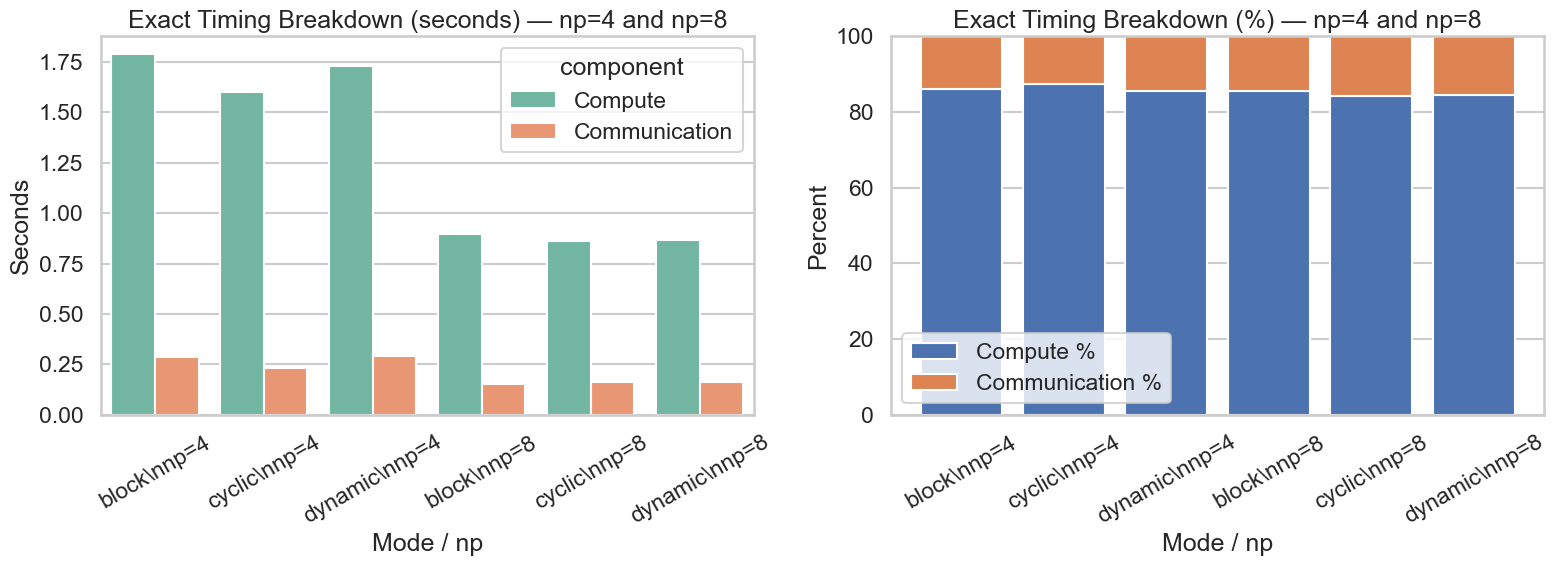

In [8]:
# Exact measured timing from instrumented Member 4 runs (C=10, m=1.1, MAX_ITER=150, K-Means++)
# Source: [member4] Total compute/communication time from MPI instrumented output
exact_timing = pd.DataFrame([
    {'mode': 'block',   'np': 4, 'total_compute_s': 1.7877, 'total_comm_s': 0.2864, 'compute_percent': 86.2, 'comm_percent': 13.8},
    {'mode': 'cyclic',  'np': 4, 'total_compute_s': 1.6034, 'total_comm_s': 0.2297, 'compute_percent': 87.5, 'comm_percent': 12.5},
    {'mode': 'dynamic', 'np': 4, 'total_compute_s': 1.7318, 'total_comm_s': 0.2929, 'compute_percent': 85.5, 'comm_percent': 14.5},
    {'mode': 'block',   'np': 8, 'total_compute_s': 0.8944, 'total_comm_s': 0.1517, 'compute_percent': 85.5, 'comm_percent': 14.5},
    {'mode': 'cyclic',  'np': 8, 'total_compute_s': 0.8593, 'total_comm_s': 0.1604, 'compute_percent': 84.3, 'comm_percent': 15.7},
    {'mode': 'dynamic', 'np': 8, 'total_compute_s': 0.8651, 'total_comm_s': 0.1602, 'compute_percent': 84.4, 'comm_percent': 15.6},
])

# If percentages are not provided, compute them from times.
if 'compute_percent' not in exact_timing.columns or exact_timing['compute_percent'].isna().all():
    denom = exact_timing['total_compute_s'] + exact_timing['total_comm_s']
    exact_timing['compute_percent'] = np.where(denom > 0, 100 * exact_timing['total_compute_s'] / denom, 0.0)
    exact_timing['comm_percent'] = np.where(denom > 0, 100 * exact_timing['total_comm_s'] / denom, 0.0)

display(exact_timing)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute times grouped by np
plot_df = exact_timing.melt(
    id_vars=['mode', 'np'],
    value_vars=['total_compute_s', 'total_comm_s'],
    var_name='component',
    value_name='seconds'
)
plot_df['component'] = plot_df['component'].map({
    'total_compute_s': 'Compute',
    'total_comm_s': 'Communication'
})
plot_df['mode_np'] = plot_df['mode'] + '\\nnp=' + plot_df['np'].astype(str)

sns.barplot(data=plot_df, x='mode_np', y='seconds', hue='component', ax=axes[0], palette='Set2')
axes[0].set_title('Exact Timing Breakdown (seconds) — np=4 and np=8')
axes[0].set_xlabel('Mode / np')
axes[0].set_ylabel('Seconds')
axes[0].tick_params(axis='x', labelrotation=30)

# Percentage stacked bars
x = np.arange(len(exact_timing))
labels = [f"{r['mode']}\\nnp={r['np']}" for _, r in exact_timing.iterrows()]
axes[1].bar(x, exact_timing['compute_percent'], label='Compute %')
axes[1].bar(x, exact_timing['comm_percent'], bottom=exact_timing['compute_percent'], label='Communication %')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=30)
axes[1].set_title('Exact Timing Breakdown (%) — np=4 and np=8')
axes[1].set_xlabel('Mode / np')
axes[1].set_ylabel('Percent')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()


## 5) Load Generated Member 4 CSV Outputs

Expected files from your runs:
- `viz_membership_sample.csv`
- `viz_top_terms.csv`
- `viz_label_cluster_comparison.csv`

In [9]:
required_files = [
    'viz_membership_sample.csv',
    'viz_top_terms.csv',
    'viz_label_cluster_comparison.csv'
 ]

for f in required_files:
    print(f, 'exists ->', os.path.exists(f))

membership_sample = pd.read_csv('viz_membership_sample.csv')
top_terms = pd.read_csv('viz_top_terms.csv')
label_cmp = pd.read_csv('viz_label_cluster_comparison.csv')

cluster_cols = [c for c in membership_sample.columns if c.startswith('cluster_')]
spread = (membership_sample[cluster_cols].max() - membership_sample[cluster_cols].min())
print('Max membership spread across sample columns:', float(spread.max()))

with pd.option_context('display.float_format', '{:.12f}'.format):
    display(membership_sample.head())

display(top_terms.head(15))
display(label_cmp.head())

viz_membership_sample.csv exists -> True
viz_top_terms.csv exists -> True
viz_label_cluster_comparison.csv exists -> True
Max membership spread across sample columns: 0.998020137026


,doc_id,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9
0,0,0.108857158702,0.044595741444,0.176716147205,0.044795131259,0.035877889787,0.035864739269,0.029613848872,0.038406447695,0.308556160511,0.176716735257
1,1,0.767938922435,0.007630077502,0.071780871209,0.007662589913,0.005730260447,0.006383740799,0.005673721585,0.006254371343,0.049165069383,0.071780375384
2,2,0.242941682692,0.025066454256,0.272539104196,0.025221069469,0.017566152861,0.021959222106,0.016495090873,0.020888407735,0.084784959320,0.272537856492
3,3,0.065029760937,0.108169948044,0.072200405151,0.107492476125,0.111080740109,0.080065129044,0.070300280380,0.251087968985,0.062372849284,0.072200441941
4,4,0.065029760937,0.108169948044,0.072200405151,0.107492476125,0.111080740109,0.080065129044,0.070300280380,0.251087968985,0.062372849284,0.072200441941


,cluster,rank,feature_index,feature_name,weight
0,0,1,86,breath,0.273972
1,0,2,339,shortness,0.248244
2,0,3,340,shortness breath,0.236037
3,0,4,303,present_illness,0.217938
4,0,5,207,hypertension,0.181995
5,0,6,358,systems,0.174853
6,0,7,421,the_patient,0.171056
7,0,8,93,chest_pain,0.168820
8,0,9,494,which,0.155549
9,0,10,496,who,0.153308


,label,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,dominant_cluster,dominant_ratio
0,Allergy / Immunology,0,0,1,0,0,0,0,0,3,3,8,0.428571
1,Bariatrics,4,0,4,0,1,5,0,1,1,2,5,0.277778
2,Cardiovascular / Pulmonary,78,37,18,49,33,44,38,13,28,31,0,0.211382
3,Neurology,17,6,28,8,15,4,47,0,15,83,9,0.372197
4,Dentistry,3,0,1,6,7,7,0,2,0,1,4,0.259259


## 6) Cluster Quality Visualizations

### 6.1 Membership Heatmap (Soft Assignment Quality)

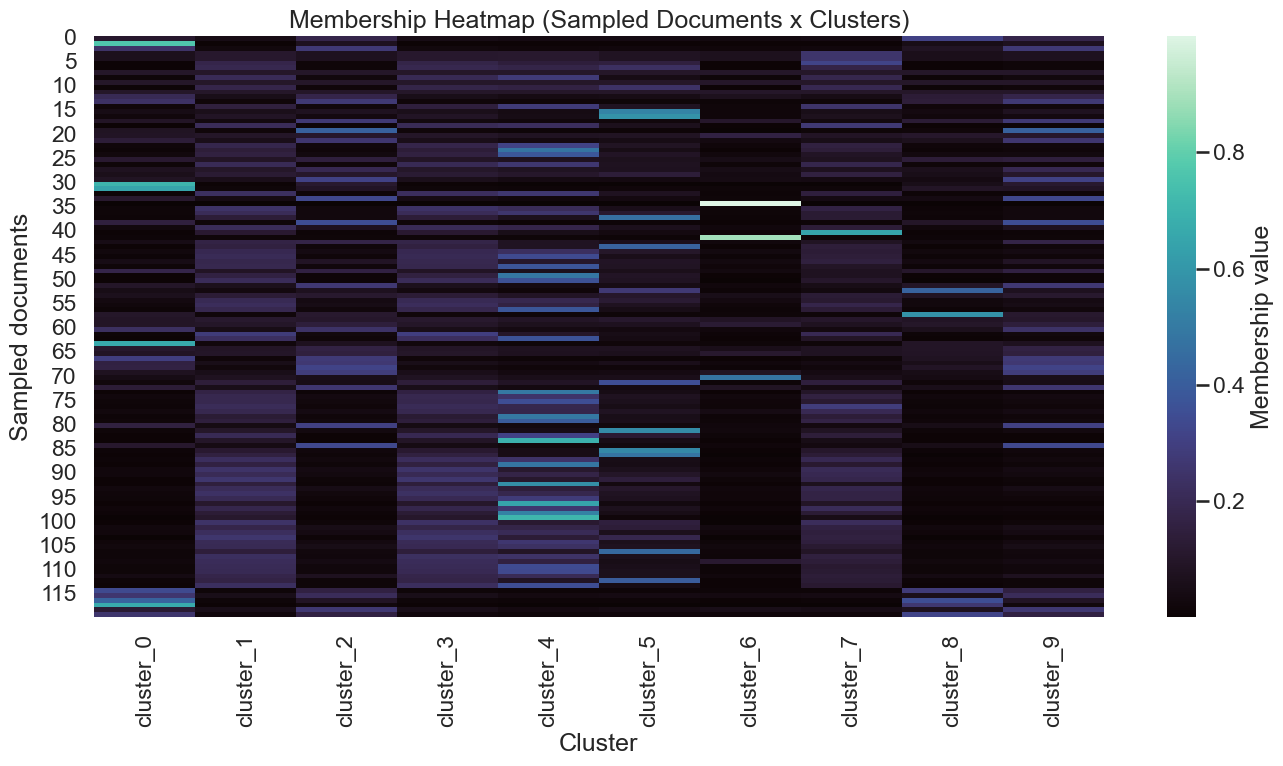

In [10]:
membership_matrix = membership_sample.drop(columns=['doc_id'], errors='ignore')

plt.figure(figsize=(14, 8))
sns.heatmap(membership_matrix, cmap='mako', cbar_kws={'label': 'Membership value'})
plt.title('Membership Heatmap (Sampled Documents x Clusters)')
plt.xlabel('Cluster')
plt.ylabel('Sampled documents')
plt.tight_layout()
plt.show()

### 6.2 Top Terms per Cluster (Bar Charts)

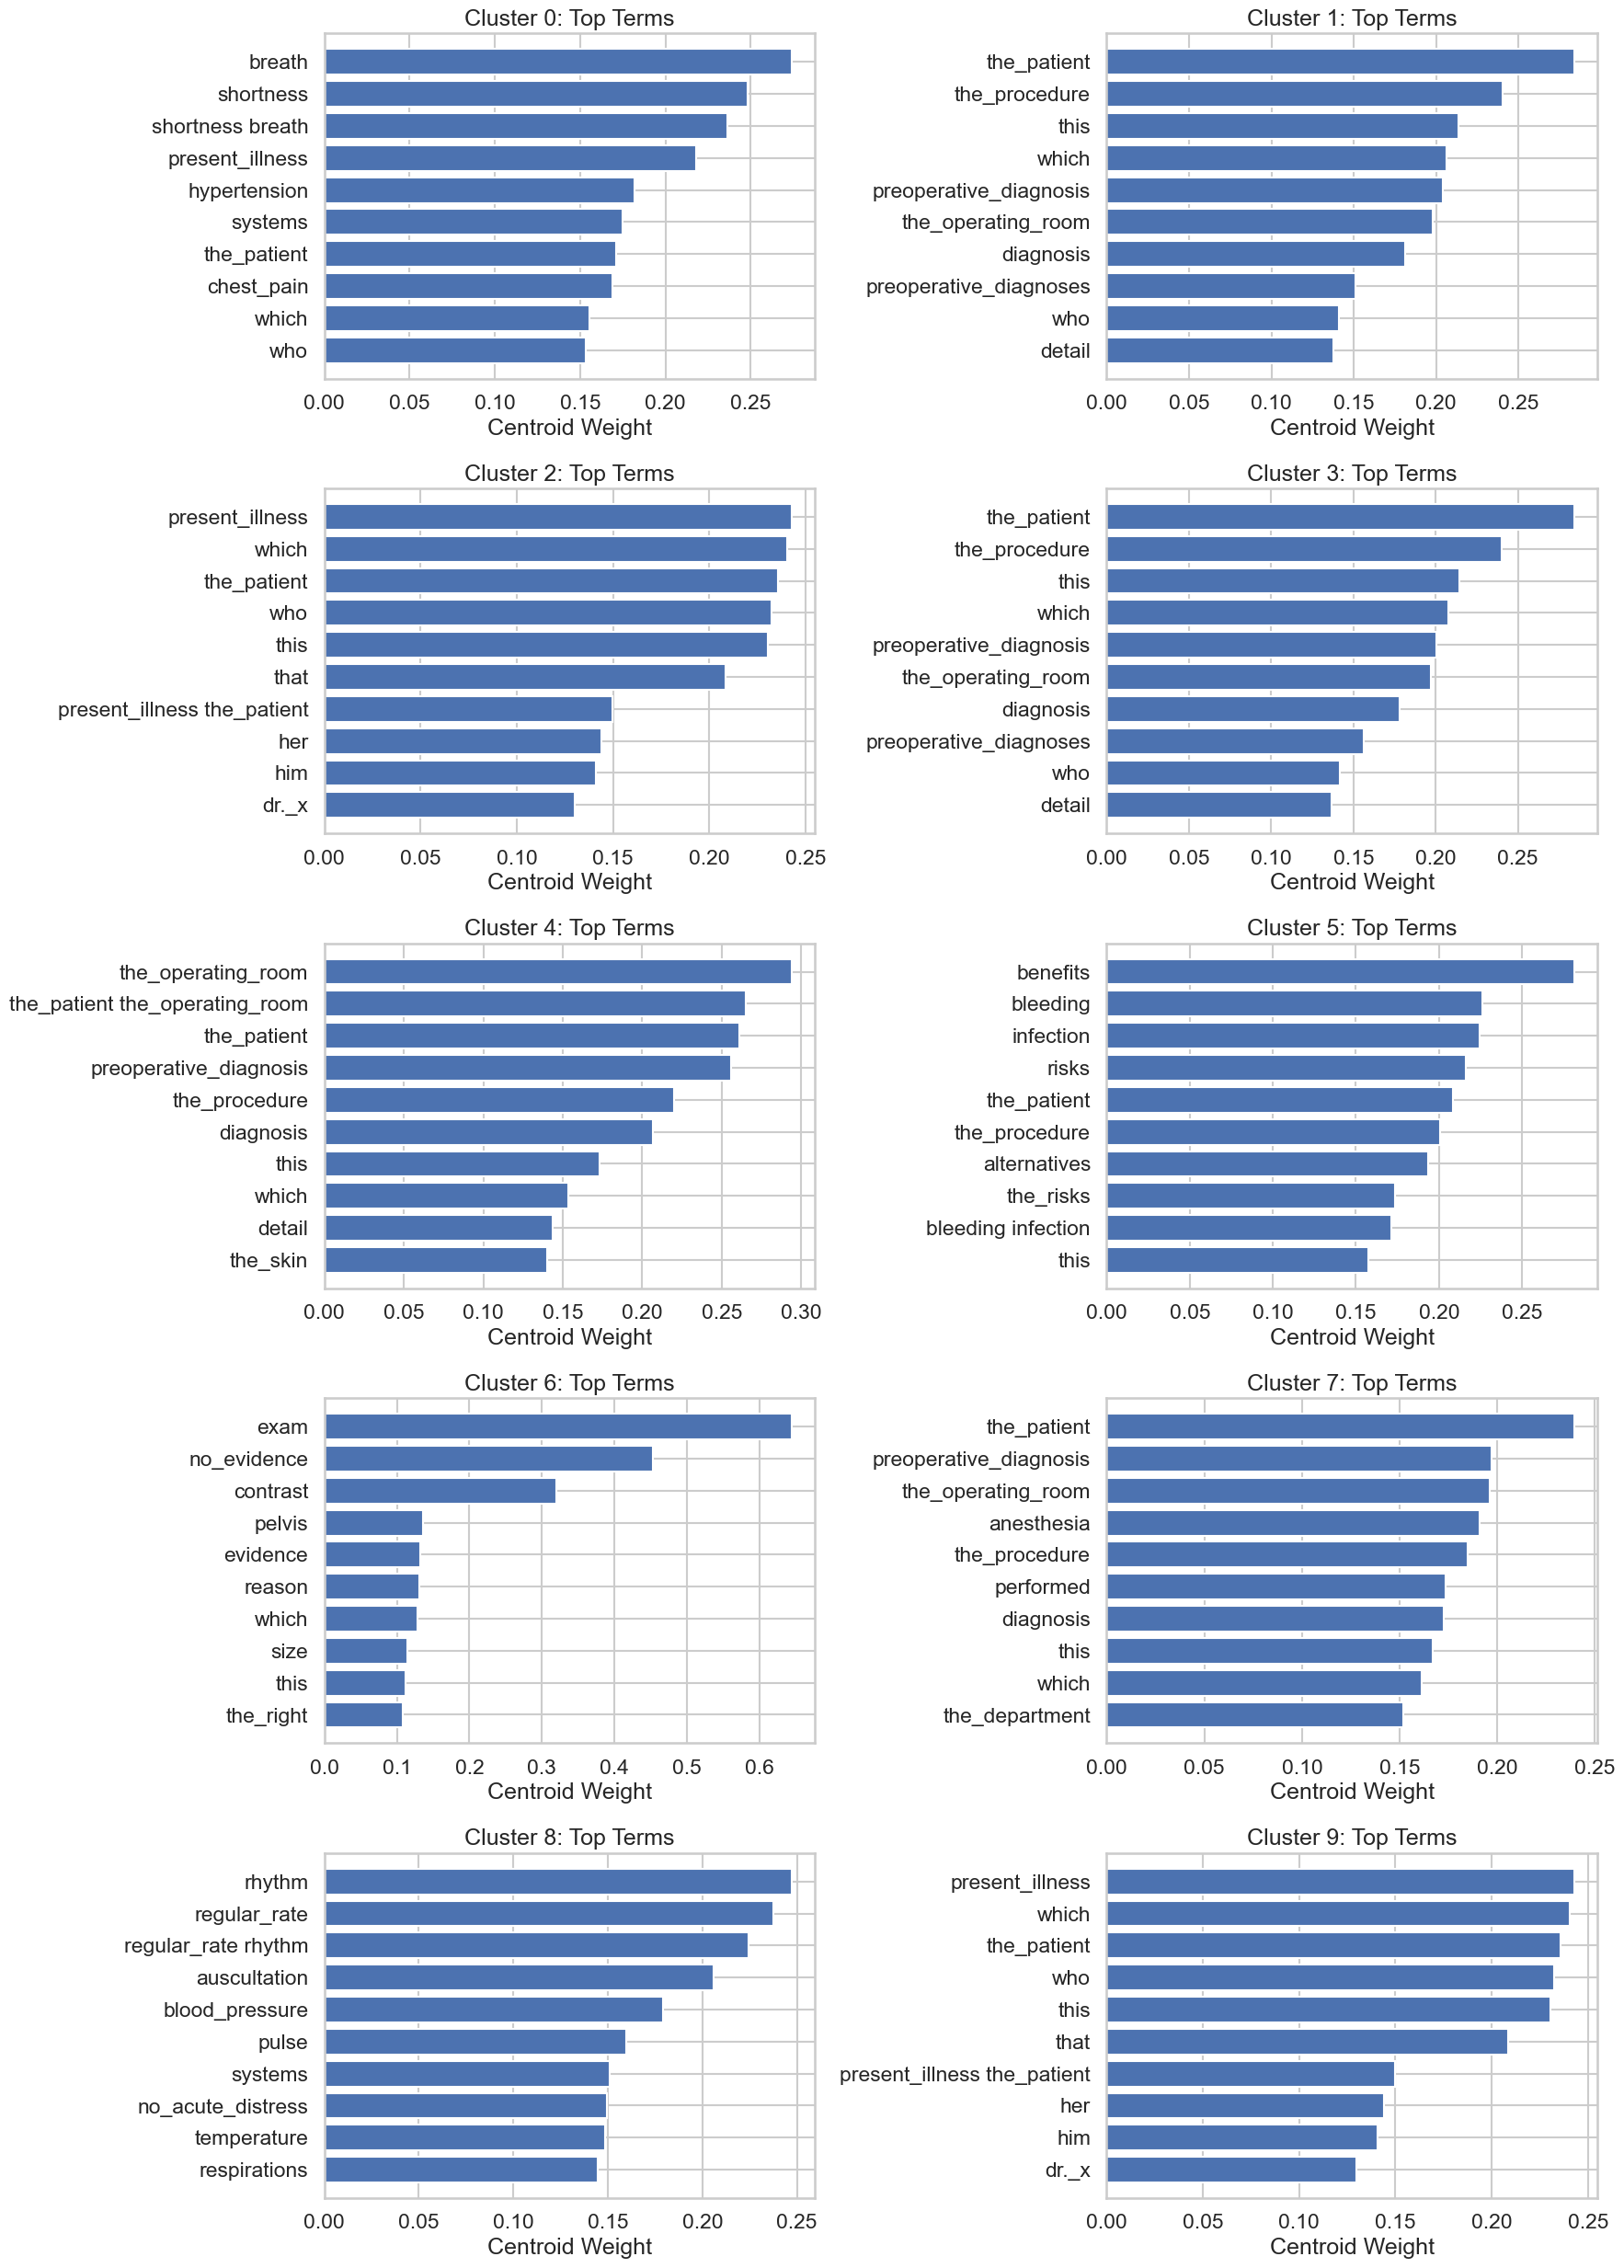

In [11]:
top_terms = top_terms.sort_values(['cluster', 'rank'])
clusters = sorted(top_terms['cluster'].unique())
ncols = 2
nrows = int(np.ceil(len(clusters) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows), squeeze=False)
for idx, c in enumerate(clusters):
    r = idx // ncols
    k = idx % ncols
    ax = axes[r][k]
    d = top_terms[top_terms['cluster'] == c].sort_values('weight', ascending=True)
    ax.barh(d['feature_name'].astype(str), d['weight'])
    ax.set_title(f'Cluster {c}: Top Terms')
    ax.set_xlabel('Centroid Weight')

# Hide empty subplot slots
for idx in range(len(clusters), nrows * ncols):
    r = idx // ncols
    k = idx % ncols
    axes[r][k].axis('off')

plt.tight_layout()
plt.show()

### 6.3 Label vs Cluster Distribution (Quantitative Alignment)

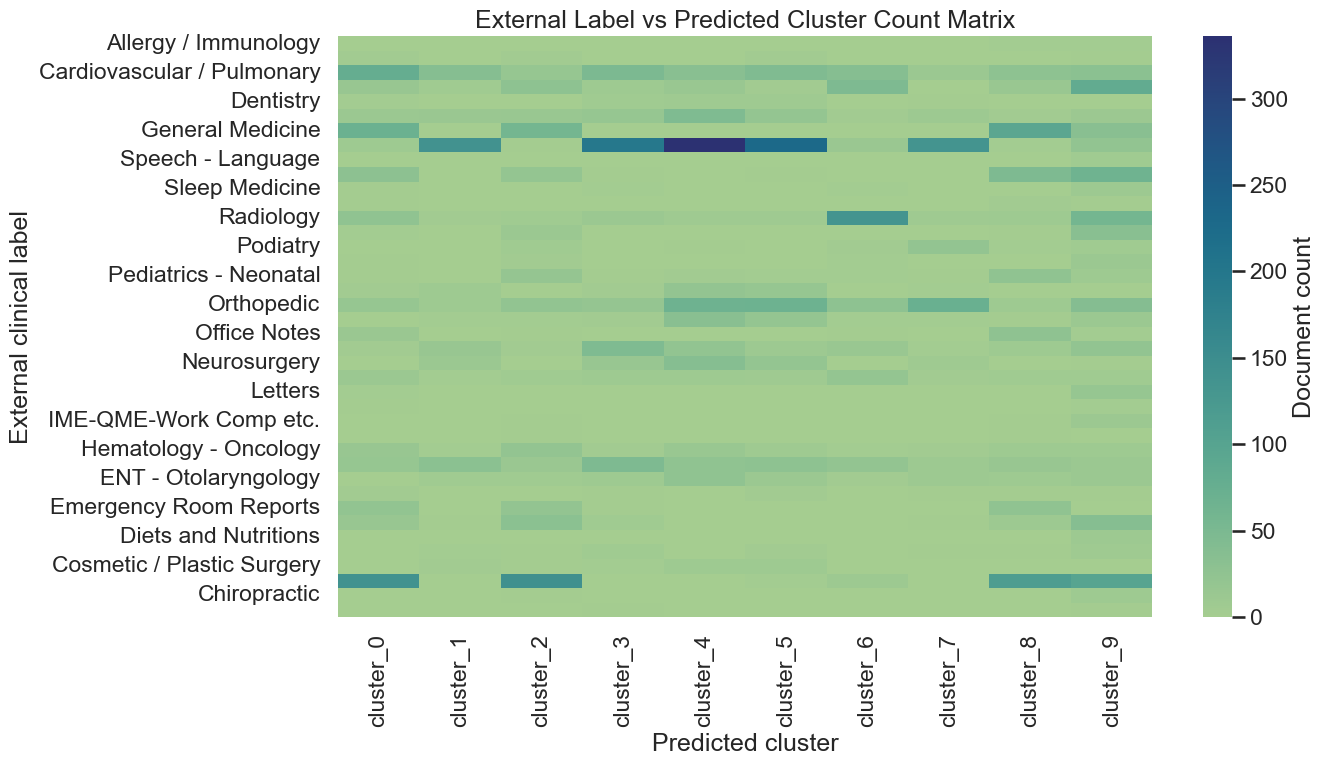

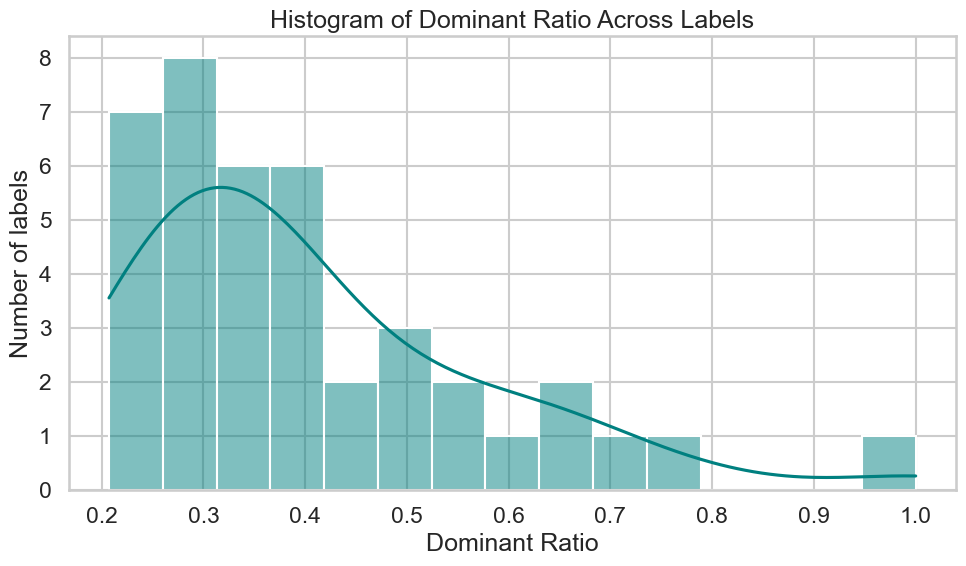

In [12]:
cluster_cols = [c for c in label_cmp.columns if c.startswith('cluster_')]
matrix = label_cmp.set_index('label')[cluster_cols]

plt.figure(figsize=(14, 8))
sns.heatmap(matrix, annot=False, cmap='crest', cbar_kws={'label': 'Document count'})
plt.title('External Label vs Predicted Cluster Count Matrix')
plt.xlabel('Predicted cluster')
plt.ylabel('External clinical label')
plt.tight_layout()
plt.show()

# Dominant ratio histogram (label purity proxy)
plt.figure(figsize=(10, 6))
sns.histplot(label_cmp['dominant_ratio'], bins=15, kde=True, color='teal')
plt.title('Histogram of Dominant Ratio Across Labels')
plt.xlabel('Dominant Ratio')
plt.ylabel('Number of labels')
plt.tight_layout()
plt.show()

## 7) Quantitative Cluster Quality Metrics

We compute weighted and macro purity indicators using `dominant_ratio`.

In [13]:
label_cmp = label_cmp.copy()
label_cmp['label_total'] = label_cmp[cluster_cols].sum(axis=1)

macro_purity = label_cmp['dominant_ratio'].mean()
weighted_purity = (label_cmp['dominant_ratio'] * label_cmp['label_total']).sum() / label_cmp['label_total'].sum()

print(f'Macro purity (mean dominant_ratio): {macro_purity:.4f}')
print(f'Weighted purity: {weighted_purity:.4f}')

label_cmp[['label', 'dominant_cluster', 'dominant_ratio', 'label_total']].sort_values('dominant_ratio', ascending=False).head(15)

Macro purity (mean dominant_ratio): 0.4044
Weighted purity: 0.3231


,label,dominant_cluster,dominant_ratio,label_total
34,Diets and Nutritions,9,1.000000,10
24,Letters,9,0.782609,23
26,IME-QME-Work Comp etc.,9,0.687500,16
8,Speech - Language,9,0.666667,9
13,Psychiatry / Psychology,9,0.641509,53
38,Chiropractic,9,0.615385,13
15,Physical Medicine - Rehab,9,0.571429,21
20,Office Notes,8,0.562500,48
11,Rheumatology,8,0.500000,10
10,Sleep Medicine,9,0.500000,20


## 8) External Clinical Knowledge Comparison (Template)

Use this dictionary to encode expected term patterns per clinical specialty and score overlap with discovered top terms.

Edit the `clinical_knowledge` mapping according to your course domain references.

Term source for overlap: centroids_mpi_kmeanspp.csv top-100
Expanded discovered vocabulary size: 810
Expanded vocabulary preview: [' lidocaine', ' vicryl', ' xylocaine', '_lidocaine', '_vicryl', '_xylocaine', 'a', 'a   blade', 'a  year old female', 'a  year old female who', 'a  year old male', 'a history', 'a sterile fashion', 'a supine position', 'a total', 'a_ _blade', 'a_ year old_female', 'a_ year old_female who', 'a_ year old_male', 'a_history', 'a_sterile_fashion', 'a_supine_position', 'a_total', 'abcd', 'abcd general hospital', 'abcd_general_hospital', 'abcdgeneralhospital', 'abdomen', 'abdominal', 'abdominal pain', 'abdominal_pain', 'abdominalpain', 'ablade', 'acute', 'addition', 'admission', 'age', 'ahistory', 'air', 'alcohol']


,clinical_label,cluster,overlap_count,jaccard_similarity,matched_terms
8,cardiology,8,4,0.020725,"blood, heart, pressure, rhythm"
0,cardiology,0,4,0.018519,"blood, coronary, heart, pressure"
2,cardiology,2,3,0.013953,"blood, coronary, pressure"
9,cardiology,9,3,0.013953,"blood, coronary, pressure"
6,cardiology,6,2,0.009050,"coronary, ecg"
5,cardiology,5,1,0.003906,blood
1,cardiology,1,1,0.003690,blood
3,cardiology,3,1,0.003690,blood
7,cardiology,7,1,0.003597,blood
4,cardiology,4,1,0.003521,blood


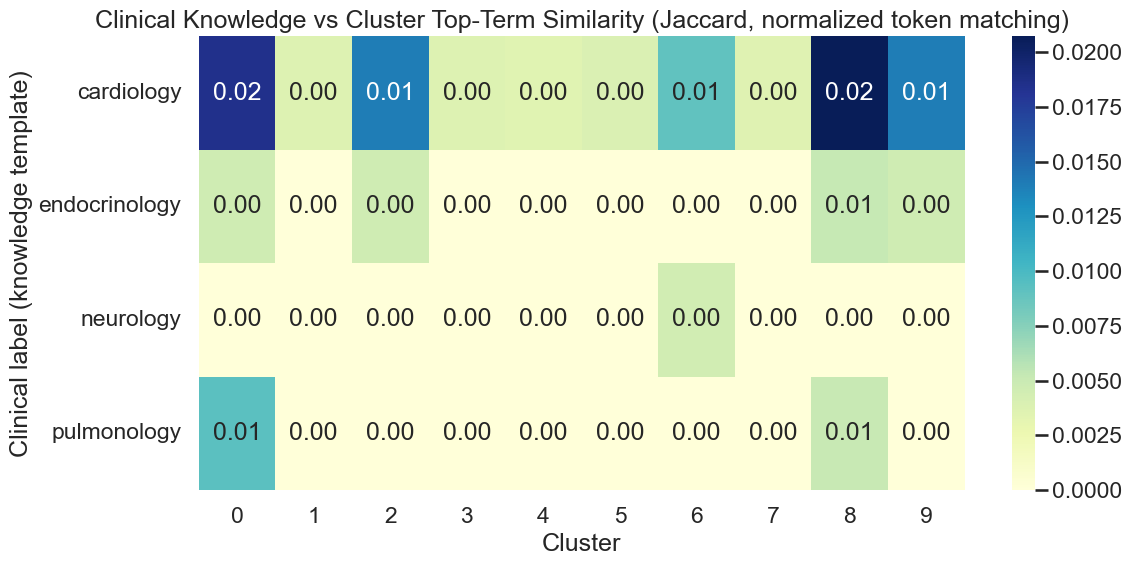

,clinical_label,cluster,overlap_count,jaccard_similarity,matched_terms
0,cardiology,8,4,0.020725,"blood, heart, pressure, rhythm"
1,endocrinology,8,1,0.005181,diabetes
2,neurology,6,1,0.004525,brain
3,pulmonology,0,2,0.009259,"asthma, respiratory"


In [14]:
import re
from collections import defaultdict

# Example template (replace with your own validated clinical references)
clinical_knowledge = {
    'cardiology': {'heart', 'cardiac', 'coronary', 'angina', 'ecg', 'blood', 'pressure', 'rhythm'},
    'neurology': {'brain', 'stroke', 'neuro', 'seizure', 'cns', 'spine', 'nerve'},
    'pulmonology': {'lung', 'respiratory', 'asthma', 'copd', 'oxygen', 'airway'},
    'endocrinology': {'diabetes', 'insulin', 'thyroid', 'glucose', 'hormone'}
}

# Domain aliases: map common corpus variants to canonical clinical tokens.
alias_to_canonical = {
    'ekg': 'ecg',
    'electrocardiogram': 'ecg',
    'bp': 'blood_pressure',
    'hr': 'heart_rate',
}

def normalize_text(s: str) -> str:
    s = str(s).lower().strip()
    s = re.sub(r'[^a-z0-9_ ]+', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

def expand_term(term: str) -> set[str]:
    """Return multiple normalized views so phrase tokens can match single clinical words."""
    t = normalize_text(term)
    forms = set()
    if not t:
        return forms

    forms.add(t)
    forms.add(t.replace('_', ' '))

    parts = [p for p in re.split(r'[ _]+', t) if p]
    forms.update(parts)

    compact = ''.join(parts)
    if compact:
        forms.add(compact)

    mapped = alias_to_canonical.get(t)
    if mapped:
        forms.update(expand_term(mapped))

    return forms

def build_cluster_terms_from_centroids(top_k: int = 100) -> dict:
    """Prefer richer term source than viz_top_terms (top-10) for overlap analysis."""
    if not (os.path.exists('centroids_mpi_kmeanspp.csv') and os.path.exists('feature_names.csv')):
        return {}

    centroids_df = pd.read_csv('centroids_mpi_kmeanspp.csv', header=None)
    feat_df = pd.read_csv('feature_names.csv')

    # Handle two-column schema: feature_index,feature_name
    if 'feature_name' in feat_df.columns:
        feat_names = feat_df['feature_name'].astype(str).tolist()
    elif feat_df.shape[1] >= 2:
        feat_names = feat_df.iloc[:, 1].astype(str).tolist()
    else:
        feat_names = feat_df.iloc[:, 0].astype(str).tolist()

    # Align feature-name list to centroid dimensionality.
    n_features = centroids_df.shape[1]
    if len(feat_names) < n_features:
        feat_names.extend([f'f_{i}' for i in range(len(feat_names), n_features)])
    else:
        feat_names = feat_names[:n_features]

    cluster_terms = {}
    for c in range(len(centroids_df)):
        row = centroids_df.iloc[c].to_numpy()
        top_idx = np.argsort(row)[-top_k:][::-1]
        cluster_terms[c] = [feat_names[i] for i in top_idx]
    return cluster_terms

# Prefer centroids+feature_names top-N terms; fallback to viz_top_terms.
top_k_for_overlap = 100
cluster_terms_raw = build_cluster_terms_from_centroids(top_k=top_k_for_overlap)
term_source = f'centroids_mpi_kmeanspp.csv top-{top_k_for_overlap}'
if not cluster_terms_raw:
    cluster_terms_raw = top_terms.groupby('cluster')['feature_name'].apply(lambda s: list(map(str, s))).to_dict()
    term_source = 'viz_top_terms.csv top-10 (fallback)'

cluster_terms_expanded = {}
for c, terms in cluster_terms_raw.items():
    expanded = set()
    for term in terms:
        expanded.update(expand_term(term))
    cluster_terms_expanded[c] = expanded

knowledge_expanded = {}
for label_name, expected_terms in clinical_knowledge.items():
    ex = set()
    for term in expected_terms:
        ex.update(expand_term(term))
    knowledge_expanded[label_name] = ex

rows = []
match_details = defaultdict(dict)

for label_name, expected_terms in knowledge_expanded.items():
    for c, terms in cluster_terms_expanded.items():
        overlap_terms = sorted(expected_terms & terms)
        overlap = len(overlap_terms)
        jaccard = overlap / max(1, len(expected_terms | terms))
        rows.append({
            'clinical_label': label_name,
            'cluster': c,
            'overlap_count': overlap,
            'jaccard_similarity': jaccard,
            'matched_terms': ', '.join(overlap_terms[:20])
        })
        match_details[label_name][c] = overlap_terms

knowledge_cmp = pd.DataFrame(rows).sort_values(
    ['clinical_label', 'jaccard_similarity', 'overlap_count'],
    ascending=[True, False, False]
 )

vocab_preview = sorted(set().union(*cluster_terms_expanded.values())) if cluster_terms_expanded else []
print('Term source for overlap:', term_source)
print('Expanded discovered vocabulary size:', len(vocab_preview))
print('Expanded vocabulary preview:', vocab_preview[:40])

display(knowledge_cmp.head(30))

plt.figure(figsize=(12, 6))
pivot_k = knowledge_cmp.pivot(index='clinical_label', columns='cluster', values='jaccard_similarity')
sns.heatmap(pivot_k, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Clinical Knowledge vs Cluster Top-Term Similarity (Jaccard, normalized token matching)')
plt.xlabel('Cluster')
plt.ylabel('Clinical label (knowledge template)')
plt.tight_layout()
plt.show()

best_match = knowledge_cmp.sort_values(['clinical_label', 'jaccard_similarity', 'overlap_count'], ascending=[True, False, False])
best_match = best_match.groupby('clinical_label', as_index=False).first()
display(best_match[['clinical_label', 'cluster', 'overlap_count', 'jaccard_similarity', 'matched_terms']])

In [15]:
best_mode = member4_modes.sort_values('total_wall_time_s').iloc[0]
best_delta_mode = member4_modes.sort_values('final_delta').iloc[0]

# Defensive recompute so this summary cell works even if prior metric cells were not rerun.
if 'speedup' not in baseline_scaling.columns or 'efficiency' not in baseline_scaling.columns:
    _t1 = baseline_scaling.loc[baseline_scaling['np'] == 1, 'total_wall_time_s'].iloc[0]
    baseline_scaling = baseline_scaling.copy()
    baseline_scaling['speedup'] = _t1 / baseline_scaling['total_wall_time_s']
    baseline_scaling['efficiency'] = baseline_scaling['speedup'] / baseline_scaling['np']

print('=== Member 4 Analysis Summary ===')
print(f"Baseline scaling speedup at np=8: {baseline_scaling.loc[baseline_scaling.np == 8, 'speedup'].iloc[0]:.3f}")
print(f"Baseline efficiency at np=8: {baseline_scaling.loc[baseline_scaling.np == 8, 'efficiency'].iloc[0]:.3f}")
print(f"Fastest Member 4 mode (current table): {best_mode['mode']} @ np={int(best_mode['np'])} ({best_mode['total_wall_time_s']:.4f} s)")
print(f"Lowest final delta among Member 4 modes: {best_delta_mode['mode']} @ np={int(best_delta_mode['np'])} ({best_delta_mode['final_delta']:.2e})")
print(f"Macro purity: {macro_purity:.4f}")
print(f"Weighted purity: {weighted_purity:.4f}")

if 'mode_compare' in globals():
    print('\nRelative to baseline (same np):')
    for _, row in mode_compare.sort_values('relative_improvement_percent', ascending=False).iterrows():
        print(
            f"- {row['mode']} @ np={int(row['np'])}: speedup ratio={row['relative_speedup_vs_baseline_same_np']:.3f}, "
            f"improvement={row['relative_improvement_percent']:.2f}%"
        )

if 'mode_scaling_4_to_8' in globals() and len(mode_scaling_4_to_8) > 0:
    print('\nIntra-mode scaling efficiency (4 -> 8):')
    for _, row in mode_scaling_4_to_8.iterrows():
        print(
            f"- {row['mode']}: speedup_4_to_8={row['speedup_4_to_8']:.3f}, "
            f"efficiency_4_to_8={row['efficiency_4_to_8']:.3f}"
        )

if 'exact_timing' in globals() and len(exact_timing) > 0:
    print('\nExact instrumented timing breakdown:')
    for _, row in exact_timing.iterrows():
        print(
            f"- {row['mode']} (np={int(row['np'])}): "
            f"compute={row['total_compute_s']:.4f}s ({row['compute_percent']:.1f}%), "
            f"communication={row['total_comm_s']:.4f}s ({row['comm_percent']:.1f}%)"
        )

print('\nAttribution note:')
print('- Weak/flat membership heatmaps are not attributed to Member 4 MPI implementation by default.')
print('- Member 4 execution path is valid (all modes run; synchronized centroid aggregation via MPI reductions).')
print('- Remaining limitation is primarily baseline model behavior (initialization/data geometry sensitivity).')

print(
    '\nAll core analysis artifacts generated: speedup/efficiency plots, runtime/delta/imbalance bars, '
    'relative mode comparison bars, communication-computation breakdown (proxy + exact), top terms bars, '
    'membership heatmap, label-cluster heatmap, dominant-ratio histogram.'
)

=== Member 4 Analysis Summary ===
Baseline scaling speedup at np=8: 3.228
Baseline efficiency at np=8: 0.404
Fastest Member 4 mode (current table): dynamic @ np=8 (1.0197 s)
Lowest final delta among Member 4 modes: block @ np=8 (9.41e-04)
Macro purity: 0.4044
Weighted purity: 0.3231

Relative to baseline (same np):
- dynamic @ np=8: speedup ratio=1.453, improvement=31.17%
- block @ np=8: speedup ratio=1.444, improvement=30.73%
- cyclic @ np=8: speedup ratio=1.329, improvement=24.77%
- dynamic @ np=4: speedup ratio=1.204, improvement=16.93%
- cyclic @ np=4: speedup ratio=1.177, improvement=15.02%
- block @ np=4: speedup ratio=1.001, improvement=0.12%

Intra-mode scaling efficiency (4 -> 8):
- block: speedup_4_to_8=1.945, efficiency_4_to_8=0.972
- cyclic: speedup_4_to_8=1.524, efficiency_4_to_8=0.762
- dynamic: speedup_4_to_8=1.628, efficiency_4_to_8=0.814

Exact instrumented timing breakdown:
- block (np=4): compute=1.7877s (86.2%), communication=0.2864s (13.8%)
- cyclic (np=4): compute